# 2025/11/24 Verificar funcionamiento:

## Cuando queden definidas las funciones de almacenamiento hay que agregar a cada función:
    if not os.path.exists("senales.csv"):
        # Guardar datos
        print("Se creó 'senales.csv'")
    else:
        print("El archivo ya existe, no se sobrescribió.")

In [ ]:
import numpy as np
import pandas as pd
import h5py

# Señales de ejemplo 
def generar_senales():
    dt = 20e-9
    num_points = 4000
    time_axis = np.linspace(0, (num_points - 1) * dt, num_points)
    ch1 = np.sin(2 * np.pi * 1e5 * time_axis)
    # Convertir a binario int16 con escala 25 muestras/V
    ch1_bin = 25 * ch1
    ch1_bin = ch1_bin.astype('>i2').tobytes()
    return ch1, ch1_bin, time_axis

# Crear BIN (int16): para guardar datos originales como copia de seguridad.
def create_bin_int16(data):
    with open("senales.bin", "wb") as f:
        f.write(data)
        print("Se creó 'senales.bin'")

# Crear HDF5: para almacenamiento principal y procesamiento.
def create_hdf5(time, ch1):
    with h5py.File("senales.h5", "w") as f:
        f.create_dataset("Tiempo [s]", data=time, compression="gzip")
        f.create_dataset("Tensión [V]", data=ch1, compression="gzip")
    print("Se creó 'senales.h5'")

# Crear CSV: para exportar datos.
def create_csv(time, tension):
    # Crear el DataFrame con Nombres de Columnas.
    df = pd.DataFrame({
        "Tiempo [s]": time,
        "Tensión [V]": tension
    })
    # float_format='%.4E' guarda en notación científica (ej: 1.2345E-03).
    df.to_csv("senales.csv", index=False, sep=',', float_format='%.4E')
    print("Se creó 'senales.csv'")

if __name__ == '__main__':
    ch1, ch1_bin, time_axis = generar_senales()
    create_bin_int16(ch1_bin)
    create_hdf5(time_axis, ch1)
    create_csv(time_axis, ch1)

Se creó 'senales.bin'
Se creó 'senales.h5'
Se creó 'senales.csv'


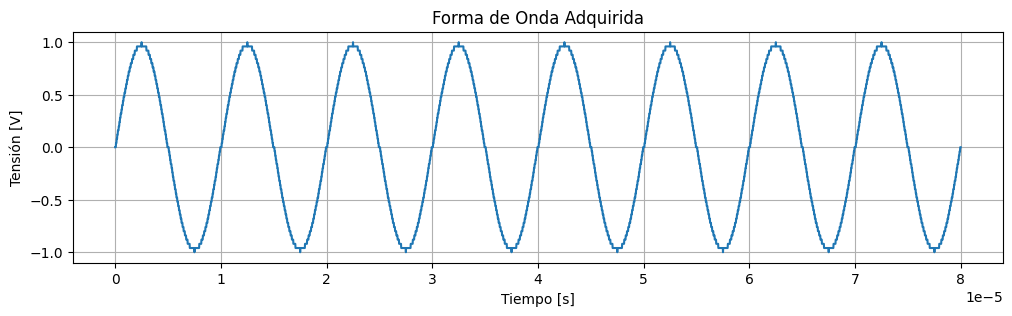

Lectura BIN: 0.0004 s, Ploteo: 0.1072 s


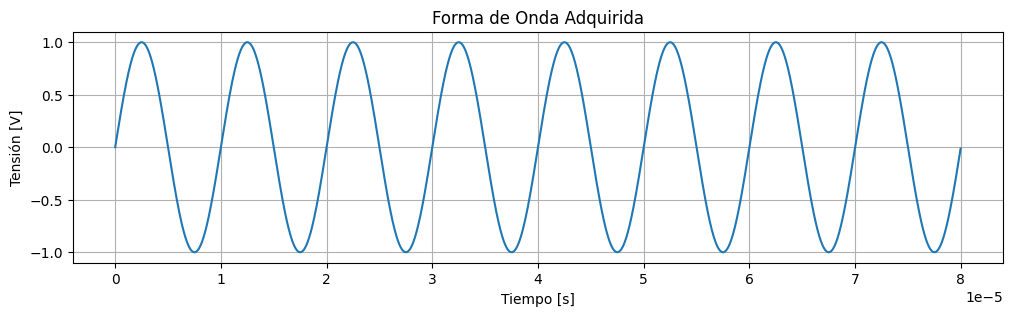

Lectura H5: 0.0122 s, Ploteo: 0.1286 s


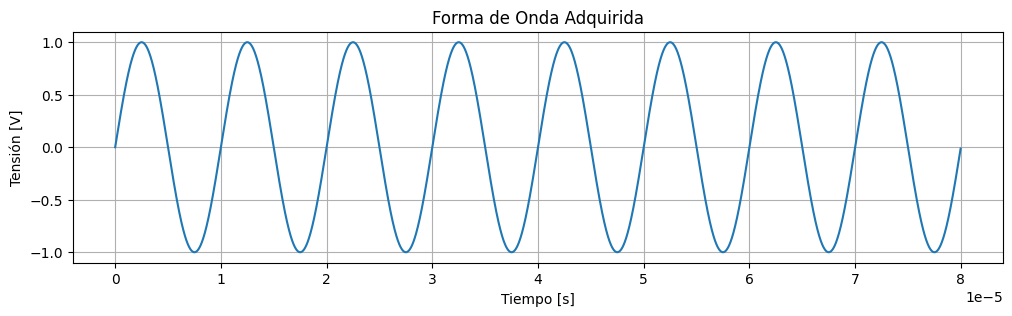

Lectura CSV: 0.0046 s, Ploteo: 0.1212 s


In [32]:
import time
from struct import unpack
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py

def read_bin():
    # dtype='>i2': Big Endian (>), 2 bytes int (i2)
    raw_data = np.fromfile("senales.bin", dtype='>i2')
    waveform = raw_data / 25.0
    return waveform

def read_csv_2():
    # 'usecols' leer SOLAMENTE esa columna.
    df = pd.read_csv("senales.csv", usecols=["Tensión [V]"])
    
    # df[titulo_columna] accede a los datos
    # .values lo convierte a un array de NumPy
    return df["Tensión [V]"].values

def read_h5():
    with h5py.File("senales.h5", "r") as f:
        return f["Tensión [V]"][:]

def plot_waveform(waveform, dt):
    num_points = len(waveform)
    time_axis = np.linspace(0, (num_points - 1) * dt, num_points)
    plt.figure(figsize=(12, 3))
    plt.plot(time_axis, waveform)
    plt.title("Forma de Onda Adquirida")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Tensión [V]")
    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    dt = 20e-9

    t0 = time.time()
    wave1 = read_bin()
    t1 = time.time()
    plot_waveform(wave1, dt)
    t2 = time.time()
    print(f"Lectura BIN: {t1 - t0:.4f} s, Ploteo: {t2 - t1:.4f} s")

    t0 = time.time()
    wave4 = read_h5()
    t1 = time.time()
    plot_waveform(wave4, dt)
    t2 = time.time()
    print(f"Lectura H5: {t1 - t0:.4f} s, Ploteo: {t2 - t1:.4f} s")
    
    t0 = time.time()
    wave5 = read_csv_2()
    t1 = time.time()
    plot_waveform(wave5, dt)
    t2 = time.time()
    print(f"Lectura CSV: {t1 - t0:.4f} s, Ploteo: {t2 - t1:.4f} s")


# Lectura de archivo .BIN con encabezado del GW Instek GDS1000A-U

Cabecera: #48008
Datos a leer: 8008 bytes
Periodo de muestreo (dt): 2.00e-08 [s] = 20 [ns]
Señal recuperada desde el archivo BIN.


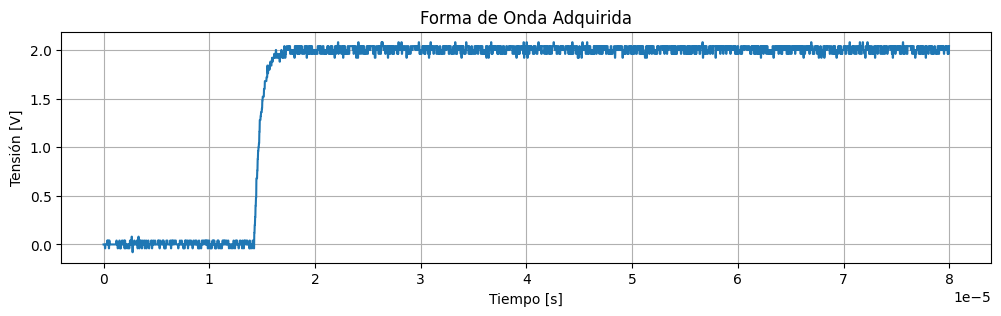

In [30]:
import numpy as np
import struct

def read_bin():
    with open('datos_osciloscopio.bin', "rb") as f:
        # Leer primeros 2 bytes (# + Digito)
        header_start = f.read(2)
        
        # Parsear el dígito de tamaño
        data_size_digit = int(chr(header_start[1]))
        
        # Leer el tamaño del bloque (los siguientes N bytes)
        size_bytes = f.read(data_size_digit)
        data_size = int(size_bytes.decode('ascii'))
        
        print("Cabecera: " + header_start.decode('ascii') + size_bytes.decode('ascii'))
        print(f"Datos a leer: {data_size} bytes")

        time_interval = f.read(8)
        # >  : Big Endian
        # f  : Float (4 bytes) -> Periodo de muestreo
        # 4x : Padding (4 bytes) -> Ignorar bloque de datos sin uso
        dt = struct.unpack('>f4x', time_interval)[0]
        
        print(f"Periodo de muestreo (dt): {dt:.2e} [s] = {dt*1e9:.0f} [ns]")
        
        # Leemos el resto del archivo (que debe coincidir con data_size)
        raw_bytes = f.read()
        
        # Validación de seguridad (opcional pero recomendada)
        if len(raw_bytes) != data_size-8:
            print(f"Advertencia: Se esperaban {data_size} bytes pero se leyeron {len(raw_bytes)}")

        raw_data = np.frombuffer(raw_bytes, dtype='>i2')
        waveform = raw_data / 25.0
        
    return waveform, dt

def plot_waveform(waveform, dt):
    num_points = len(waveform)
    time_axis = np.linspace(0, (num_points - 1) * dt, num_points)
    plt.figure(figsize=(12, 3))
    plt.plot(time_axis, waveform)
    plt.title("Forma de Onda Adquirida")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Tensión [V]")
    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    waveform, dt = read_bin()
    print(f"Señal recuperada desde el archivo BIN.")
    plot_waveform(waveform, dt)